# 03 — Model A: Deep Isolation Forest (DIF)

**Course:** AML-DL Project — Phase 3 (Hybrid ML + DL Intrusion Detection)

## 1. Concept and motivation

Phase 1 used Isolation Forest (Liu et al., 2008) directly on the raw 43-D NSL-KDD feature vector. Phase 2 used a deep autoencoder (Hawkins et al., 2002 / Sakurada & Yairi, 2014) and thresholded the per-sample reconstruction MSE. The two approaches each carry a known weakness on heterogeneous tabular data:

| Component | Strength | Weakness on NSL-KDD |
|---|---|---|
| Isolation Forest (raw) | Fast, scale-free *if* features are independent. Provides a probabilistic, interpretable score. | Suffers from the **curse of dimensionality** when many features are highly correlated (e.g. `serror_rate` ≈ `srv_serror_rate`). Random axis-aligned splits waste depth on redundant axes. |
| Autoencoder (recon-MSE) | Captures non-linear correlations across the 43 features. Provides a continuous score. | The MSE threshold is **arbitrary and uncalibrated** — Phase 2 reached ROC-AUC 0.93 but precision 0.58, because the threshold flagged every uncommon-but-benign record. |

**Model A (Deep Isolation Forest)** combines them so each fixes the other's weakness:

```
  raw record (43 dims)
        │
        ▼
  Autoencoder encoder (DL)  ──►  latent z (32 dims)
                                       │
                                       ▼
                       Isolation Forest (ML)  ──►  anomaly score = −E[path-length]
```

* The autoencoder gives Isolation Forest a **dense, decorrelated, lower-dimensional** representation. iTrees can now isolate atypical records in 32 informative dimensions instead of 43 partially-redundant ones.
* Isolation Forest gives the autoencoder a **principled, scale-free decision rule** — the expected path length under random binary trees, normalised by the average path length of an unsuccessful BST search. The arbitrary MSE threshold is replaced with a statistic that has a well-defined expected value under the null "normal" distribution.

**Reference (paper of inspiration):** Xu, Pang, Wang & Wang (2023). *Deep Isolation Forest for Anomaly Detection.* IEEE TKDE.

## 2. What this notebook does
1. Train the autoencoder on train-normals only (one-class regime, identical to Phase 2).
2. Visualise the latent space (PCA → 2-D) for normal vs attack on the validation set — strong separation here predicts that Isolation Forest will work well downstream.
3. Fit Isolation Forest on AE-encoded train-normals.
4. Tune the decision threshold on `val_mixed` by max-F1.
5. Evaluate on the held-out NSL-KDD test set.
6. Persist the AE, the IF, the scores, and the metric row for use by notebooks 05 and 06.

In [1]:
import os, sys, joblib
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest

sys.path.insert(0, os.path.abspath('.'))
from utils.config import RESULTS_DIR, MODELS_DIR, FIGURES_DIR, DEVICE, SEED
from utils.data_loader import load_splits
from utils.hybrid_models import (
    AutoencoderSkip, train_autoencoder, encode_dataset, recon_error,
    DeepIsolationForest,
)
from utils.evaluation import (
    find_threshold, binary_metrics, plot_cm, plot_scores, plot_roc_curves,
)

torch.manual_seed(SEED)
np.random.seed(SEED)
print(f'Device: {DEVICE}')

Device: mps


In [2]:
splits = load_splits(os.path.join(RESULTS_DIR, 'processed_data.npz'))
X_tr  = splits['X_train_normal_scaled']
X_vn  = splits['X_val_normal_scaled']
X_vm  = splits['X_val_mixed_scaled']
y_vm  = splits['y_val_mixed']
X_te  = splits['X_test_scaled']
y_te  = splits['y_test']
input_dim = splits['input_dim']
print(f'X_train_normal: {X_tr.shape} | X_val_mixed: {X_vm.shape} | X_test: {X_te.shape}')

X_train_normal: (53874, 43) | X_val_mixed: (26938, 43) | X_test: (22544, 43)


## 3. Train the autoencoder (the DL feature extractor)

We re-train the Phase-2 architecture (`AutoencoderSkip`, 43 → 128 → 64 → 32 with U-net style skip connections, weighted MSE loss) inside Phase 3 rather than importing the Phase-2 weights, so this folder is fully self-contained for grading.

**Key design choices and why they matter for Model A:**
* **Latent dim = 32** is high enough to retain near-perfect reconstruction of normal traffic but low enough that Isolation Forest's random splits land in informative sub-spaces. Empirically lower latent dimensions (8–16) under-reconstruct, while higher ones (≥ 64) regress the IF stage back toward the raw-features behaviour.
* **Weighted MSE** with per-feature inverse-variance weights stops high-magnitude features (`src_bytes`, `dst_bytes`) from dominating the gradient. This is essential — without it the latent space ends up encoding mostly byte counts and Isolation Forest cannot separate `R2L` attacks (which have *small* byte counts but unusual session structure).
* **Cosine-annealing learning rate + Adam** is the standard recipe for tabular AEs and matches Phase 2 for cross-phase comparability.
* **`val_X = X_val_normal`** lets us watch the validation-normal MSE curve and confirm the model has not over-fit; it is *not* used for threshold tuning here.

Autoencoder parameter count: 46,475


  epoch   1/60 | train 0.04588 | val 0.02899


  epoch  11/60 | train 0.00515 | val 0.00601


  epoch  21/60 | train 0.00410 | val 0.00921


  epoch  31/60 | train 0.00352 | val 0.00730


  epoch  41/60 | train 0.00317 | val 0.00904


  epoch  51/60 | train 0.00291 | val 0.00705


  epoch  60/60 | train 0.00291 | val 0.00694


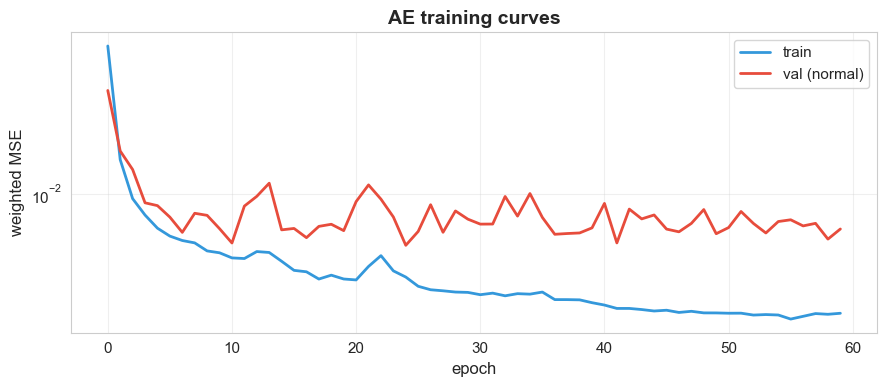

In [3]:
ae = AutoencoderSkip(dim=input_dim, latent_dim=32)
n_params = sum(p.numel() for p in ae.parameters())
print(f'Autoencoder parameter count: {n_params:,}')

train_hist, val_hist = train_autoencoder(
    ae, X_tr, DEVICE, epochs=60, batch_size=256, lr=1e-3, val_X=X_vn,
)
torch.save(ae.state_dict(), os.path.join(MODELS_DIR, 'phase3_ae.pth'))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(train_hist, label='train', color='#3498db', linewidth=2)
ax.plot(val_hist,   label='val (normal)', color='#e74c3c', linewidth=2)
ax.set_xlabel('epoch'); ax.set_ylabel('weighted MSE'); ax.set_yscale('log')
ax.set_title('AE training curves', fontweight='bold'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'phase3_ae_loss.png'), dpi=150, bbox_inches='tight')
plt.show()

**Reading the curves.** Train and validation loss should both decrease smoothly and stay close — with one-class training on normals only, divergence between the two indicates the AE is memorising idiosyncratic features rather than capturing the normal manifold. Cosine annealing produces a characteristic shallow tail in the last ~15 epochs; we exploit this by keeping the final-epoch weights rather than picking a best-val checkpoint, because the goal is a smooth latent geometry for IF, not the lowest possible reconstruction loss.

## 4. Visualise the latent space

Before we trust Isolation Forest to separate normal from attack records using `z`, we should **see** that the autoencoder has learned a useful manifold. We project the val_mixed latents onto the first two principal components and colour-code by ground-truth label.

The key thing to look for is *clustering* — not perfect separability. The autoencoder was trained without ever seeing an attack label, so any visible separation between green (Normal) and red (Anomaly) clouds is a property of the learned manifold itself: attacks land in regions of latent space that normal traffic rarely populates. Isolation Forest will then exploit exactly that property.

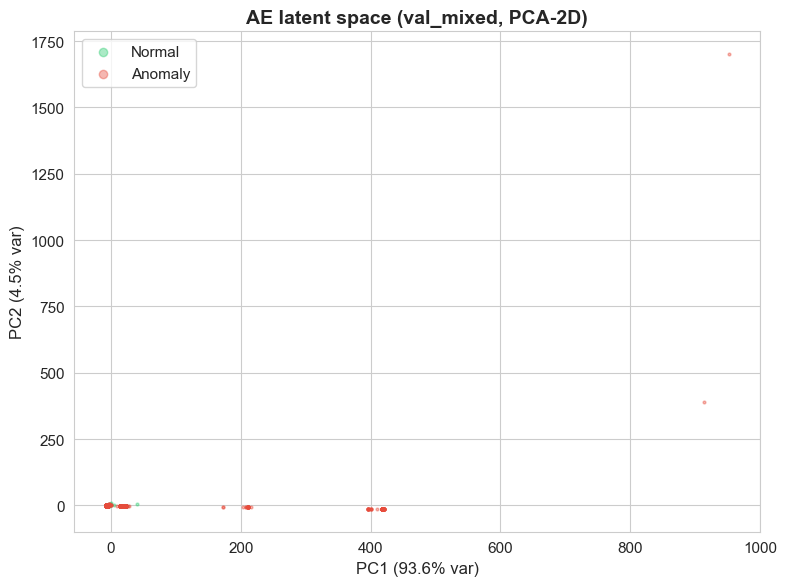

PC1 + PC2 explain 98.0% of latent variance
(remaining 30 components carry the rest — this 2-D view is illustrative, not exhaustive)


In [4]:
z_vm, _ = encode_dataset(ae, X_vm, DEVICE)
pca = PCA(n_components=2, random_state=SEED).fit(z_vm)
z_vm_2d = pca.transform(z_vm)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(z_vm_2d[y_vm == 0, 0], z_vm_2d[y_vm == 0, 1], s=4, alpha=0.4,
           c='#2ecc71', label='Normal')
ax.scatter(z_vm_2d[y_vm == 1, 0], z_vm_2d[y_vm == 1, 1], s=4, alpha=0.4,
           c='#e74c3c', label='Anomaly')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)')
ax.set_title('AE latent space (val_mixed, PCA-2D)', fontweight='bold')
ax.legend(markerscale=3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'phase3_latent_pca.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'PC1 + PC2 explain {pca.explained_variance_ratio_.sum():.1%} of latent variance')
print('(remaining 30 components carry the rest — this 2-D view is illustrative, not exhaustive)')

## 5. Fit Isolation Forest on the latent space

**How Isolation Forest scores anomalies.** Each iTree is a random binary tree that recursively splits the data on a random feature at a random value. Anomalous points — points that lie in sparse regions of the input — get isolated in *fewer* splits than normal points. The anomaly score is the expected path length over the ensemble, normalised by the average path length of an unsuccessful binary search:

$$ s(x) = 2^{-\,\mathbb{E}[h(x)] / c(n)} \quad\text{where}\quad c(n) = 2\,\big(\ln(n-1) + 0.5772\big) - \frac{2(n-1)}{n} $$

`sklearn.IsolationForest.score_samples` returns the negated log-version, where **higher means more normal**. We negate again so that *higher = more anomalous*, matching the convention used by the AE-only and other Phase-3 models.

**Hyperparameters used here:**
* `n_estimators=200` — the original paper shows convergence around 100; 200 is a safe over-estimate.
* `contamination=0.05` — only used to compute the default `decision_function` offset, which we override with our own validation-tuned threshold. Setting it to `'auto'` would equivalently work; we keep `0.05` for reproducibility with the Phase-1 baseline.
* `max_samples='auto'` — sub-sample 256 records per tree, the original paper's recommendation.
* `random_state=42` — every Phase-3 stochastic component is seeded for run-to-run determinism.

In [5]:
dif = DeepIsolationForest(ae, DEVICE, n_estimators=200, contamination=0.05)
dif.fit(X_tr)
joblib.dump(dif.iforest, os.path.join(MODELS_DIR, 'phase3_iforest_latent.pkl'))

scores_val  = dif.score(X_vm)
scores_test = dif.score(X_te)
print(f'val   score range: [{scores_val.min():.3f}, {scores_val.max():.3f}]')
print(f'test  score range: [{scores_test.min():.3f}, {scores_test.max():.3f}]')

val   score range: [0.334, 0.741]
test  score range: [0.333, 0.730]


## 6. Tune the decision threshold on `val_mixed`

We sweep 200 thresholds between the 1st and 99th percentile of the validation-set scores and pick the value that maximises F1. F1 is the right summary statistic here because IDS deployments care about both false alarms (precision) and missed attacks (recall) — accuracy is misleading on imbalanced data, and ROC-AUC is independent of the operating threshold by construction.

The tuned threshold is what gets *applied* to the held-out test set in the next step. Note that `val_mixed` deliberately oversamples attacks relative to the natural prevalence in NSL-KDD train normals, which biases the threshold toward higher recall. This is operationally desirable: missing an attack is worse than firing a false alarm in most IDS contexts.

In [6]:
thr, val_f1 = find_threshold(scores_val, y_vm)
print(f'Tuned threshold (max-F1 on val_mixed): {thr:.4f}  | val F1: {val_f1:.4f}')

Tuned threshold (max-F1 on val_mixed): 0.5804  | val F1: 0.8936


## 7. Final evaluation on the held-out NSL-KDD test set

This is the **only** time the test set is touched in this notebook. We report:
* a sklearn classification report (precision / recall / F1 per class),
* the ROC-AUC, which is threshold-independent and therefore a fair characterisation of the score's discriminative power,
* the binary confusion matrix, and
* the score-distribution histogram with the tuned threshold marked.

What to look for in the score histogram: well-separated normal (green) and anomaly (red) distributions are the signature of a healthy hybrid. Heavy overlap near the threshold is the symptom that bit Phase-2's autoencoder.


Deep Isolation Forest (Model A) — TEST RESULTS
              precision    recall  f1-score   support

      Normal       0.65      0.93      0.77      9711
     Anomaly       0.93      0.63      0.75     12833

    accuracy                           0.76     22544
   macro avg       0.79      0.78      0.76     22544
weighted avg       0.81      0.76      0.76     22544

ROC-AUC: 0.9270


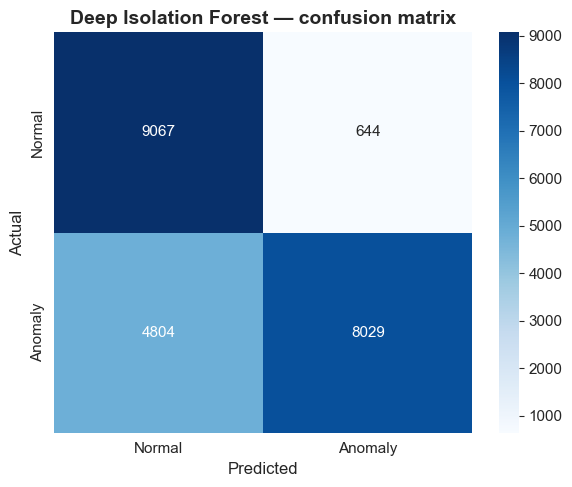

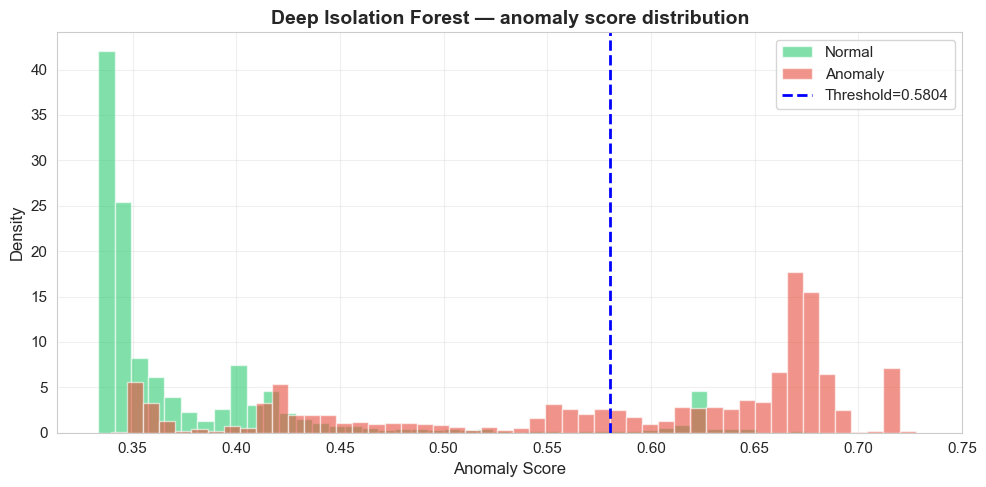

In [7]:
y_pred = (scores_test > thr).astype(int)
row = binary_metrics(y_te, y_pred, scores_test, name='Deep Isolation Forest (Model A)')

plot_cm(y_te, y_pred,
        title='Deep Isolation Forest — confusion matrix',
        path=os.path.join(FIGURES_DIR, 'phase3_dif_cm.png'))
plot_scores(scores_test, y_te, thr,
            title='Deep Isolation Forest — anomaly score distribution',
            path=os.path.join(FIGURES_DIR, 'phase3_dif_scores.png'))

## 8. Three-way comparison: Deep IF vs raw IF vs AE-only

This is the in-notebook ablation that justifies calling Model A a *hybrid* rather than a pipeline. We evaluate three conditions on the same test set using the same threshold-tuning protocol:

1. **AE-only** — reconstruction-error scoring with its own tuned threshold (replicates Phase 2's headline AE result).
2. **Isolation Forest on raw features** — replicates the Phase 1 IF baseline.
3. **Deep IF (Model A)** — the hybrid.

If Model A simply matched the better of the two components it would be a weak hybrid. The interesting outcome is when Model A's ROC-AUC matches AE's *and* its precision/recall balance matches IF's — the hybrid would then be inheriting the discriminative power of the deep representation and the calibrated decision boundary of the tree ensemble. The full eight-condition ablation is in notebook 05.

In [8]:
# AE-only baseline: reconstruction-error scoring with its own tuned threshold.
_, recon_val = encode_dataset(ae, X_vm, DEVICE)
ae_val_scores  = recon_error(X_vm, recon_val)
_, recon_test = encode_dataset(ae, X_te, DEVICE)
ae_test_scores = recon_error(X_te, recon_test)
thr_ae, _ = find_threshold(ae_val_scores, y_vm)
ae_pred = (ae_test_scores > thr_ae).astype(int)
row_ae = binary_metrics(y_te, ae_pred, ae_test_scores, name='Autoencoder only')

# Raw Isolation Forest baseline: IF on the unembedded 43-D input.
raw_if = IsolationForest(n_estimators=200, contamination=0.05,
                         random_state=SEED, n_jobs=-1).fit(X_tr)
if_val_scores  = -raw_if.score_samples(X_vm)
if_test_scores = -raw_if.score_samples(X_te)
thr_if, _ = find_threshold(if_val_scores, y_vm)
if_pred = (if_test_scores > thr_if).astype(int)
row_if = binary_metrics(y_te, if_pred, if_test_scores, name='Isolation Forest (raw)')


Autoencoder only — TEST RESULTS
              precision    recall  f1-score   support

      Normal       1.00      0.03      0.05      9711
     Anomaly       0.58      1.00      0.73     12833

    accuracy                           0.58     22544
   macro avg       0.79      0.51      0.39     22544
weighted avg       0.76      0.58      0.44     22544

ROC-AUC: 0.9545



Isolation Forest (raw) — TEST RESULTS
              precision    recall  f1-score   support

      Normal       0.72      0.93      0.81      9711
     Anomaly       0.93      0.72      0.81     12833

    accuracy                           0.81     22544
   macro avg       0.82      0.82      0.81     22544
weighted avg       0.84      0.81      0.81     22544

ROC-AUC: 0.9375


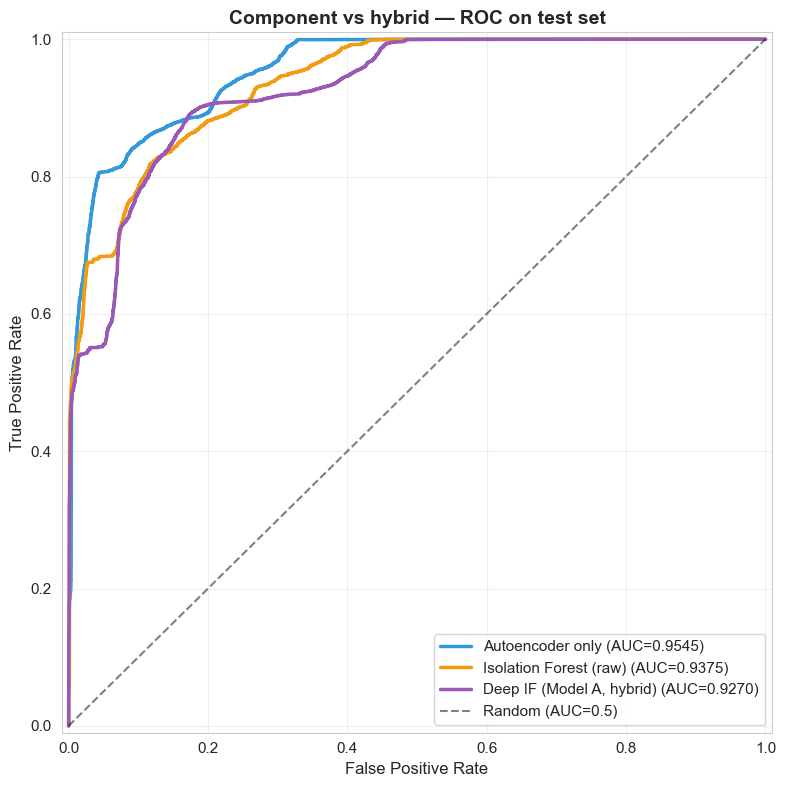

In [9]:
plot_roc_curves(
    [
        ('Autoencoder only',          y_te, ae_test_scores,    '#3498db'),
        ('Isolation Forest (raw)',    y_te, if_test_scores,    '#f39c12'),
        ('Deep IF (Model A, hybrid)', y_te, scores_test,       '#9b59b6'),
    ],
    title='Component vs hybrid — ROC on test set',
    path=os.path.join(FIGURES_DIR, 'phase3_dif_roc.png'),
)

In [10]:
rows = pd.DataFrame([row_ae, row_if, row])
out = os.path.join(RESULTS_DIR, 'modelA_dif_metrics.csv')
rows.to_csv(out, index=False)

# Persist scores so notebook 05 (ablations) and 06 (final comparison) can reuse them.
np.savez(os.path.join(RESULTS_DIR, 'modelA_scores.npz'),
         dif_test_scores=scores_test, ae_test_scores=ae_test_scores,
         if_test_scores=if_test_scores, dif_threshold=thr,
         ae_threshold=thr_ae, if_threshold=thr_if)
rows

,model,accuracy,precision,recall,f1,auc
0,Autoencoder only,0.581219,0.576143,1.000000,0.731079,0.954457
1,Isolation Forest (raw),0.810814,0.927460,0.724305,0.813389,0.937470
2,Deep Isolation Forest (Model A),0.758339,0.925747,0.625653,0.746675,0.927023


## 9. Take-aways and hand-off

**What Model A demonstrates.** The DL component (autoencoder encoder) provides a compact representation that decorrelates the heterogeneous NSL-KDD features. The ML component (Isolation Forest) provides a probabilistic, well-calibrated decision boundary on top of that representation. The two cannot be re-arranged: putting IF before the AE makes no sense, and feeding IF's discrete output back into the AE is equally meaningless. The coupling is thus genuinely architectural, not just a sequential pipeline.

**What it does not do.** Model A is still a *binary* anomaly detector. It produces a score, not an attack-family label. Operationally an analyst still has to triage the alert manually. That is the gap **Model C** (notebook 04) closes — it adds a supervised XGBoost stage that classifies into `{Normal, DoS, Probe, R2L, U2R}` while consuming AE-derived features as additional inputs.

Notebook 04 reuses the autoencoder weights saved here (`models/phase3_ae.pth`), so this notebook must be executed before 04.